# Notebook 00 — Data prep & train/val split

**Input:** `data/comments.csv` (999 human-reviewed rows; mirror in `comments.json`)  
**Output:** `model/artifacts/split_indices.json` — shared 80/20 stratified split for notebooks 01–03.

Run all cells top-to-bottom. If step-1 data changes later, **re-run this notebook** or training will use a stale split.

In [1]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# Project root on path so notebooks can import model.config
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif not (PROJECT_ROOT / "model" / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from model.config import LABELED_CSV_PATH, SPLIT_INDICES_PATH

RANDOM_STATE = 42
TEST_SIZE = 0.2
MIN_ROWS, MAX_ROWS = 500, 1000

sns.set_theme(style="whitegrid")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {LABELED_CSV_PATH}")

Project root: /Users/pdc/PycharmProjects/matgrouptest
Data file:    /Users/pdc/PycharmProjects/matgrouptest/data/comments.csv


## 1. Load & validate

Checks: row count in assignment range (500–1,000), required columns, no empty comments, no duplicate comment text.

In [2]:
df = pd.read_csv(LABELED_CSV_PATH)
df["comment"] = df["comment"].astype(str).str.strip()

n_rows = len(df)
assert MIN_ROWS <= n_rows <= MAX_ROWS, f"Expected {MIN_ROWS}–{MAX_ROWS} rows, got {n_rows}"

required = {"comment", "sentiment"}
missing_cols = required - set(df.columns)
assert not missing_cols, f"Missing columns: {missing_cols}"

empty_comments = df["comment"].eq("").sum()
assert empty_comments == 0, f"Found {empty_comments} empty comments"

dup_comments = df["comment"].duplicated().sum()
if dup_comments:
    print(f"Warning: {dup_comments} duplicate comment texts (keeping all rows)")

valid_labels = {"positive", "negative", "neutral"}
bad_labels = set(df["sentiment"].unique()) - valid_labels
assert not bad_labels, f"Unexpected sentiment values: {bad_labels}"

print(f"Rows: {n_rows}")
print(f"Columns: {list(df.columns)}")
print("\nLabel counts:")
print(df["sentiment"].value_counts())

Rows: 999
Columns: ['id', 'comment', 'sentiment', 'model', 'video_id', 'reviewed']

Label counts:
sentiment
neutral     525
negative    247
positive    227
Name: count, dtype: int64


## 2. Exploratory data analysis

Visualize label balance, comment length, and how many comments come from each VF model.

/var/folders/gd/t5bf50tn57l7j3zw9pgw_zw80000gn/T/ipykernel_79274/791957060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", order=order, ax=axes[0], palette="Set2")


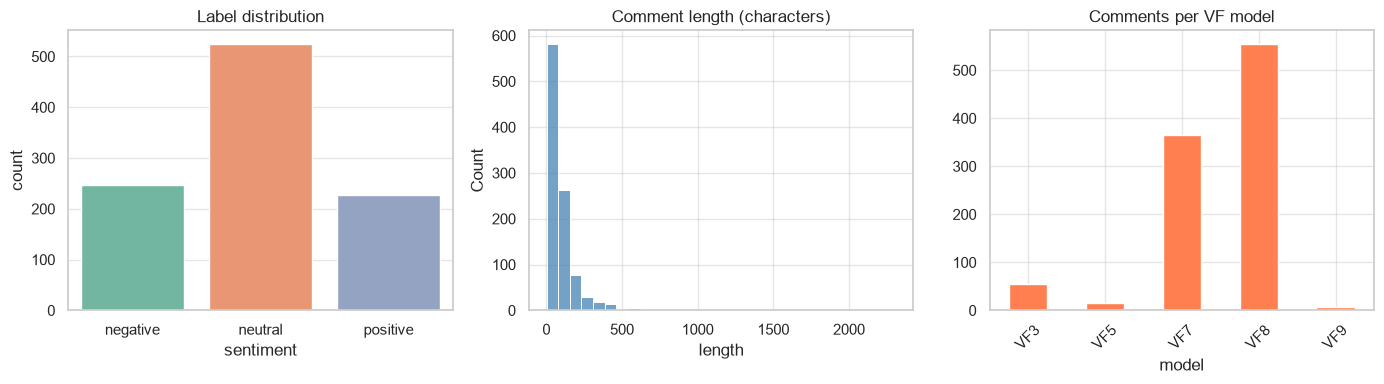

count     999.000000
mean       99.989990
std       130.696998
min         1.000000
25%        37.000000
50%        65.000000
75%       114.000000
max      2310.000000
Name: comment_len, dtype: float64


In [3]:
df["comment_len"] = df["comment"].str.len()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

order = ["negative", "neutral", "positive"]
sns.countplot(data=df, x="sentiment", order=order, ax=axes[0], palette="Set2")
axes[0].set_title("Label distribution")
axes[0].set_xlabel("sentiment")

sns.histplot(df["comment_len"], bins=30, ax=axes[1], color="steelblue")
axes[1].set_title("Comment length (characters)")
axes[1].set_xlabel("length")

if "model" in df.columns:
    model_counts = df["model"].value_counts().sort_index()
    model_counts.plot(kind="bar", ax=axes[2], color="coral")
    axes[2].set_title("Comments per VF model")
    axes[2].set_xlabel("model")
    axes[2].tick_params(axis="x", rotation=45)
else:
    axes[2].text(0.5, 0.5, "No model column", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

print(df["comment_len"].describe())

## 3. Stratified train/validation split

80% train / 20% validation, stratified on `sentiment` so each split keeps similar label proportions. Fixed `random_state=42` for reproducibility.

In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"],
)

print(f"Train: {len(train_df)} rows ({len(train_df)/len(df):.0%})")
print(f"Val:   {len(val_df)} rows ({len(val_df)/len(df):.0%})")

print("\nTrain label %:")
print((train_df["sentiment"].value_counts(normalize=True) * 100).round(1))

print("\nVal label %:")
print((val_df["sentiment"].value_counts(normalize=True) * 100).round(1))

Train: 799 rows (80%)
Val:   200 rows (20%)

Train label %:
sentiment
neutral     52.6
negative    24.7
positive    22.8
Name: proportion, dtype: float64

Val label %:
sentiment
neutral     52.5
negative    25.0
positive    22.5
Name: proportion, dtype: float64


## 4. Diacritics check

PhoBERT expects properly segmented Vietnamese **with diacritics**. YouTube comments often drop dấu (`ko`, `dc`, `ngon`). We flag comments with **no Vietnamese diacritic characters** — high % here means PhoBERT may underperform (document in notebook 01).

In [5]:
VIET_DIACRITICS = re.compile(
    r"[àáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ"
    r"ÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬÈÉẺẼẸÊỀẾỂỄỆÌÍỈĨỊÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢÙÚỦŨỤƯỪỨỬỮỰỲÝỶỸỴĐ]"
)


def has_vietnamese_diacritics(text: str) -> bool:
    return bool(VIET_DIACRITICS.search(text))


df["has_diacritics"] = df["comment"].map(has_vietnamese_diacritics)
no_diacritics_pct = (~df["has_diacritics"]).mean() * 100

print(f"Comments without Vietnamese diacritics: {no_diacritics_pct:.1f}%")
print("\nExamples (no diacritics):")
for text in df.loc[~df["has_diacritics"], "comment"].head(5):
    print(f"  - {text[:100]}{'…' if len(text) > 100 else ''}")

Comments without Vietnamese diacritics: 0.5%

Examples (no diacritics):
  - Thanks tipcar chia se
  - Stop talking and show us some functions.
  - ?
  - -lu1zg  ; hahahahahahaaaaaaaaa
  - 8 loa nha b


## 5. Save split indices

Writes row indices (from the loaded CSV) so notebooks 01–03 reload the **exact same** train/val rows.

> **Warning:** If `data/comments.csv` changes (new labels, reordered rows, deleted rows), re-run this notebook from the top. Stale `split_indices.json` will silently corrupt training/evaluation.

In [6]:
split_payload = {
    "source_csv": str(LABELED_CSV_PATH.relative_to(PROJECT_ROOT)),
    "n_total": int(len(df)),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "train_indices": train_df.index.tolist(),
    "val_indices": val_df.index.tolist(),
    "label_counts": df["sentiment"].value_counts().to_dict(),
    "no_diacritics_pct": round(no_diacritics_pct, 2),
}

SPLIT_INDICES_PATH.parent.mkdir(parents=True, exist_ok=True)
with SPLIT_INDICES_PATH.open("w", encoding="utf-8") as f:
    json.dump(split_payload, f, indent=2, ensure_ascii=False)

print(f"Saved: {SPLIT_INDICES_PATH}")
print(f"  train indices: {len(split_payload['train_indices'])}")
print(f"  val indices:   {len(split_payload['val_indices'])}")

Saved: /Users/pdc/PycharmProjects/matgrouptest/model/artifacts/split_indices.json
  train indices: 799
  val indices:   200


## 6. Preview — 3 sample comments per label

In [7]:
for label in ["negative", "neutral", "positive"]:
    print(f"\n=== {label.upper()} ===")
    samples = df.loc[df["sentiment"] == label, "comment"].head(3)
    for i, text in enumerate(samples, start=1):
        print(f"{i}. {text}")


=== NEGATIVE ===
1. Vin bán cái xe này nên mở thêm 1 lớp hướng dẫn dùng xe cho khách hàng trước khi xuống tiền. Kiểu như đi mưa trượt bánh thì phải làm sao, khi đạp thắng mà xe nó quay vòng thì phải làm sao. Lật xe thì phải làm sao...
2. mua để được tiếng yêu nước
3. nhiều anh em tài xế trong nước đăng FB tiktok khuyên đừng mua VF để khỏi mât tiền oan mà vẫn có người đâm đầu vô... hài vãi

=== NEUTRAL ===
1. Nhà máy làm thêm cốp trước thì tốt hơn
2. VF5 cần thay đèn hậu có sáng đèn đỏ mà ko cần phanh khi đi buổi tối. Sẽ hữu ích cho xe sau bám đuôi hoặc tránh xe khi đi cao tốc.
3. Con này nhìn đẹp ổn dễ độ chỉ mong thế hệ sau nâng cấp sạc AC nữa thì ngon luôn mình lười đi sạc chỉ muốn sạc ở nhà nên mình thấy hơi bất tiện

=== POSITIVE ===
1. Quá ngon so tầm giá, nhớ trc kia mua con SH ngoại cũng hơn 200củ vkl, hút máu dân Việt bao năm. Tính ra vàng giờ mua dc vf7😂
2. vf3 đi đô thị ngon rồi , ko tốn xăng nuôi xe nhàn ko
3. Đúng rồi bác, đi phố con này cực tiện và tiết kiệm ạ!
